# Tecnicas de balanceo en series CGM con coherencia clinica

Este notebook analiza tecnicas de balanceo aplicadas a escenarios reales generados en 00_Experiments.ipynb. El foco no es solo ejecutar metodos, sino evaluar como cada tecnica interactua con la temporalidad, la estructura episodica, la autocorrelacion y la continuidad clinica de las series CGM. La discusion conecta los hallazgos del EDA con el comportamiento esperado de cada tecnica y con los riesgos metodologicos asociados a alterar series fisiologicas.

## Setup y carga de escenarios

Se cargan los escenarios experimentales construidos a partir de datos reales. La estructura de columnas se mantiene consistente con el EDA: identificador de paciente, timestamp, glucosa continua, etiqueta clinica, episodios y segmentos. Las funciones siguientes garantizan trazabilidad y permiten evaluar los cambios introducidos por cada tecnica sin romper la continuidad fisiologica.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

def locate_experiments_dir():
    paths = [
        Path('data/processed/experiments'),
        Path('../04_Experiments/data/processed/experiments'),
        Path('../../data/processed/experiments'),
        Path('notebooks/04_Experiments/data/processed/experiments')
    ]
    for p in paths:
        if p.exists() and any(p.glob('*.parquet')):
            return p
    raise FileNotFoundError('No se pudo encontrar el directorio de experimentos (.parquet).')

exp_dir = locate_experiments_dir()
print(f'Directorio de experimentos detectado: {exp_dir.resolve()}')

def list_experiments(exp_dir: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(exp_dir.glob('*.parquet')):
        rows.append({'experiment': p.stem, 'path': str(p)})
    return pd.DataFrame(rows)

catalog = list_experiments(exp_dir)
display(catalog)

Directorio de experimentos detectado: C:\Users\User\Desktop\TFM-Glucose-Prediction\notebooks\04_Experiments\data\processed\experiments


,experiment,path
0,expA_imbalance_leve_replacebg,..\04_Experiments\data\processed\experiments\e...
1,expB_imbalance_moderado_replacebg,..\04_Experiments\data\processed\experiments\e...
2,expC_imbalance_severo_diatrend,..\04_Experiments\data\processed\experiments\e...
3,expD_imbalance_extremo_diatrend,..\04_Experiments\data\processed\experiments\e...
4,expE_concentracion_hypo_diatrend,..\04_Experiments\data\processed\experiments\e...
5,expF_heterogeneidad_paciente_diatrend,..\04_Experiments\data\processed\experiments\e...
6,expG_fragmentacion_t1dgranada,..\04_Experiments\data\processed\experiments\e...
7,expH_perdida_continuidad_t1dgranada,..\04_Experiments\data\processed\experiments\e...
8,expI_reduccion_frecuencia_t1dgranada,..\04_Experiments\data\processed\experiments\e...
9,expJ_episodios_cortos_replacebg,..\04_Experiments\data\processed\experiments\e...


## Metricas de evaluacion temporal y fisiologica

El objetivo es cuantificar si una tecnica altera la autocorrelacion, introduce cambios bruscos no fisiologicos o distorsiona la distribucion de clases. Se calcula autocorrelacion promedio por paciente y violaciones de tasa de cambio (RoC) sobre pasos con frecuencia nominal, evitando pasos que atraviesan gaps.

In [2]:
def load_experiment(name: str) -> pd.DataFrame:
    path = exp_dir / f'{name}.parquet'
    if not path.exists():
        raise FileNotFoundError(f'No existe el experimento: {name}')
    df = pd.read_parquet(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    return df

def compute_autocorr(df: pd.DataFrame, lag: int = 1) -> float:
    corrs = []
    for _, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp')
        if len(g) > lag:
            c = g['glucose'].autocorr(lag=lag)
            if not pd.isna(c):
                corrs.append(c)
    return float(np.mean(corrs)) if corrs else float('nan')

def check_roc_violations(df: pd.DataFrame, freq_min: int = 5, roc_threshold: float = 3.0) -> tuple[int, float]:
    total_violations = 0
    total_valid = 0
    for _, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp')
        dt = g['timestamp'].diff().dt.total_seconds().div(60)
        dg = g['glucose'].diff().abs()
        roc = dg / dt
        valid = (dt > 0) & (dt <= freq_min * 1.5)
        valid_roc = roc[valid]
        total_violations += int((valid_roc > roc_threshold).sum())
        total_valid += int(valid_roc.shape[0])
    pct = (total_violations / total_valid * 100) if total_valid > 0 else 0.0
    return total_violations, pct

def summarize_dataset(df: pd.DataFrame, label: str) -> pd.DataFrame:
    counts = df['class_label'].value_counts(normalize=True) * 100
    freq_min = int(df['freq_min'].iloc[0]) if 'freq_min' in df.columns else 5
    autocorr = compute_autocorr(df)
    viols, pct = check_roc_violations(df, freq_min=freq_min)
    out = pd.DataFrame({
        'metric': ['n_rows', 'n_patients', 'pct_hypo', 'pct_normo', 'pct_hyper', 'autocorr_lag1', 'roc_violations', 'roc_pct'],
        'value': [
            len(df),
            df['patient_id'].nunique(),
            float(counts.get('hypoglycemia', 0.0)),
            float(counts.get('normoglycemia', 0.0)),
            float(counts.get('hyperglycemia', 0.0)),
            float(autocorr),
            int(viols),
            float(pct)
        ]
    })
    out['dataset'] = label
    return out

## T1 — Random Oversampling episodico

Fundamento teorico: se replica la unidad clinica completa en lugar de puntos aislados. Esta decision preserva la autocorrelacion interna del episodio y evita saltos no fisiologicos. La tecnica asume que duplicar episodios completos no agrega informacion nueva, pero reduce el sesgo por escasez de eventos en escenarios de hipoglucemia rara.

Cuando funciona: en DIATREND, donde los episodios son breves y muy escasos, duplicar episodios completos mantiene la coherencia temporal y evita que la clase minoritaria sea ignorada.

Cuando falla: si un paciente tiene muy pocos episodios distintos, la duplicacion induce sobreajuste y puede reforzar patrones idiosincraticos no generalizables.

Relacion con autocorrelacion e implicaciones fisiologicas: preserva la autocorrelacion local al mantener el orden interno, pero puede crear autocorrelacion global artificial si se repiten bloques sin variabilidad.

In [3]:
def ros_episode(df: pd.DataFrame, target_ratio: float, seed: int) -> pd.DataFrame:
    rng_local = np.random.default_rng(seed)
    out = []
    for pid, g in df.groupby('patient_id', sort=False):
        g = g.sort_values('timestamp').reset_index(drop=True)
        n_min = int((g['class_label'] == 'hypoglycemia').sum())
        n_total = len(g)
        n_other = n_total - n_min
        if n_other <= 0:
            out.append(g)
            continue
        n_target = int((target_ratio * n_other) / (1 - target_ratio))
        if n_target <= n_min:
            out.append(g)
            continue
        episodes = g[g['class_label'] == 'hypoglycemia'].groupby('episode_id', sort=False)
        episode_list = [ep for _, ep in episodes]
        if not episode_list:
            out.append(g)
            continue
        needed = n_target - n_min
        added_blocks = []
        count = 0
        idx = 0
        while count < needed:
            ep = episode_list[rng_local.integers(0, len(episode_list))]
            b = ep.copy().reset_index(drop=True)
            b['episode_id'] = f'{pid}_synth_ros_{idx}'
            added_blocks.append(b)
            count += len(b)
            idx += 1
        dup = pd.concat(added_blocks, ignore_index=True)
        freq_min = int(g['freq_min'].iloc[0]) if 'freq_min' in g.columns else 5
        base_time = g['timestamp'].max() + pd.Timedelta(minutes=freq_min)
        dup['timestamp'] = pd.date_range(base_time, periods=len(dup), freq=f'{freq_min}min')
        dup['segment_id'] = f'{pid}_synth'
        out.append(pd.concat([g, dup], ignore_index=True))
    return pd.concat(out, ignore_index=True)

## T2 — Random Undersampling temporal con preservacion de contexto

Fundamento teorico: se reduce la clase mayoritaria eliminando puntos normales alejados de transiciones clinicas, preservando una ventana de contexto alrededor de hipo e hiper. La hipotesis es que los segmentos estables aportan menos informacion que las transiciones, pero sin destruir la continuidad inmediata del episodio.

Cuando funciona: en REPLACE-BG y T1DiabetesGranada, donde los periodos de normoglucemia son largos y altamente autocorrelados. Reducir esos tramos puede disminuir sesgo y coste computacional sin perder senal relevante.

Cuando falla: si el contexto temporal es demasiado corto, se elimina historia necesaria para predecir descensos. Si se ignoran segmentos, se pueden crear gaps no fisiologicos.

Relacion con autocorrelacion e implicaciones fisiologicas: reduce autocorrelacion de normoglucemia pero protege las zonas de cambio, que son clinicamente mas informativas.

In [4]:
def rus_temporal(df: pd.DataFrame, context_steps: int, keep_ratio: float, seed: int) -> pd.DataFrame:
    rng_local = np.random.default_rng(seed)
    out = []
    for pid, g in df.groupby('patient_id', sort=False):
        g = g.sort_values('timestamp').reset_index(drop=True)
        interest = g['class_label'].isin(['hypoglycemia', 'hyperglycemia']).values
        context = interest.copy()
        n = len(g)
        for i in range(n):
            if interest[i]:
                start = max(0, i - context_steps)
                end = min(n, i + context_steps + 1)
                context[start:end] = True
        distant = np.where(~context)[0]
        if len(distant) == 0:
            out.append(g)
            continue
        n_keep = int(len(distant) * keep_ratio)
        keep_idx = rng_local.choice(distant, size=n_keep, replace=False) if n_keep > 0 else np.array([], dtype=int)
        keep_mask = np.zeros(n, dtype=bool)
        keep_mask[context] = True
        keep_mask[keep_idx] = True
        out.append(g[keep_mask])
    return pd.concat(out, ignore_index=True)

## T3 — Cost-sensitive learning

Fundamento teorico: se ajustan pesos en la funcion de perdida segun la frecuencia de clases. No altera datos ni episodios, por lo que es la tecnica mas segura desde el punto de vista fisiologico y temporal.

Cuando funciona: como baseline en cualquier escenario, especialmente cuando se desea evitar cualquier alteracion de la continuidad o autocorrelacion.

Cuando falla: en desbalanceos extremos puede generar inestabilidad de optimizacion y exceso de falsos positivos, afectando la utilidad clinica.

Relacion con autocorrelacion e implicaciones fisiologicas: preserva por completo la estructura temporal y la distribucion real de episodios.

In [5]:
def compute_class_weights(df: pd.DataFrame) -> dict:
    counts = df['class_label'].value_counts()
    total = len(df)
    n_classes = len(counts)
    weights = {cls: total / (n_classes * count) for cls, count in counts.items()}
    return weights

## T4 — SMOTE adaptado temporalmente

Fundamento teorico: se interpola dentro del mismo paciente y segmento temporal, evitando mezclar dinamicas de sujetos distintos y evitando cruzar gaps. La hipotesis es que vecinos cercanos dentro de un mismo contexto fisiologico producen variaciones plausibles.

Cuando funciona: en datasets con episodios persistentes y autocorrelacion alta, donde existen suficientes vecinos temporales dentro de un mismo paciente (REPLACE-BG, T1DiabetesGranada).

Cuando falla: en episodios muy cortos o escasos (DIATREND), la vecindad temporal es insuficiente y la interpolacion puede suavizar transiciones clinicas relevantes.

Relacion con autocorrelacion e implicaciones fisiologicas: puede preservar autocorrelacion local si se limita la ventana temporal y se respeta el segmento; de lo contrario, introduce artefactos.

In [6]:
def smote_temporal(df: pd.DataFrame, window_size: int, target_ratio: float, max_gap_steps: int, seed: int) -> pd.DataFrame:
    rng_local = np.random.default_rng(seed)
    out = []
    for pid, g in df.groupby('patient_id', sort=False):
        g = g.sort_values('timestamp').reset_index(drop=True)
        n = len(g)
        if n <= window_size:
            out.append(g)
            continue
        X = np.array([g['glucose'].values[i:i+window_size] for i in range(n - window_size + 1)])
        labels = g['class_label'].values[window_size - 1:]
        segs = g['segment_id'].values[window_size - 1:]
        hypo_idx = np.where(labels == 'hypoglycemia')[0]
        normal_idx = np.where(labels != 'hypoglycemia')[0]
        if len(hypo_idx) < 2:
            out.append(g)
            continue
        n_target = int((target_ratio * len(normal_idx)) / (1 - target_ratio))
        n_to_gen = n_target - len(hypo_idx)
        if n_to_gen <= 0:
            out.append(g)
            continue
        generated = []
        for _ in range(n_to_gen):
            idx_a = rng_local.choice(hypo_idx)
            seg_a = segs[idx_a]
            candidates = [i for i in hypo_idx if segs[i] == seg_a and abs(i - idx_a) <= max_gap_steps and i != idx_a]
            if not candidates:
                candidates = [i for i in hypo_idx if i != idx_a]
            if not candidates:
                continue
            idx_b = rng_local.choice(candidates)
            x_a = X[idx_a]
            x_b = X[idx_b]
            lam = rng_local.uniform(0, 1)
            x_new = x_a + lam * (x_b - x_a)
            generated.append(np.clip(np.round(x_new), 39, 401))
        if not generated:
            out.append(g)
            continue
        synth = []
        freq_min = int(g['freq_min'].iloc[0]) if 'freq_min' in g.columns else 5
        base_time = g['timestamp'].max() + pd.Timedelta(minutes=freq_min)
        for idx, win in enumerate(generated):
            for step, val in enumerate(win):
                synth.append({
                    'patient_id': pid,
                    'timestamp': base_time + pd.Timedelta(minutes=freq_min * (idx * window_size + step)),
                    'glucose': float(val),
                    'class_label': 'hypoglycemia' if val < 70 else ('hyperglycemia' if val > 180 else 'normoglycemia'),
                    'segment_id': f'{pid}_synth',
                    'episode_id': f'{pid}_synth_smote_{idx}',
                    'dataset': g['dataset'].iloc[0],
                    'freq_min': freq_min
                })
        df_synth = pd.DataFrame(synth)
        out.append(pd.concat([g, df_synth], ignore_index=True))
    return pd.concat(out, ignore_index=True)

## T5 — ADASYN

Fundamento teorico: genera mas muestras en regiones del espacio de caracteristicas donde el clasificador es mas incierto. En CGM estas regiones suelen coincidir con transiciones cerca de 70 mg/dL, lo que puede inducir artefactos si se ignora la temporalidad.

Cuando funciona: como comparador metodologico en escenarios tabulares. En series CGM debe tratarse con cautela y con restricciones temporales si se busca algun uso.

Cuando falla: con autocorrelacion alta y episodios persistentes, puede introducir saltos no fisiologicos y degradar la coherencia temporal.

Relacion con autocorrelacion e implicaciones fisiologicas: tiende a reducir la autocorrelacion al introducir puntos sinteticos fuera de episodios reales.

In [7]:
def adasyn_window(df: pd.DataFrame, window_size: int, target_ratio: float, seed: int) -> pd.DataFrame:
    try:
        from imblearn.over_sampling import ADASYN
    except Exception:
        print('ADASYN no disponible en el entorno.')
        return df.copy()
    out = []
    for pid, g in df.groupby('patient_id', sort=False):
        g = g.sort_values('timestamp').reset_index(drop=True)
        n = len(g)
        if n <= window_size:
            out.append(g)
            continue
        X = np.array([g['glucose'].values[i:i+window_size] for i in range(n - window_size + 1)])
        labels = g['class_label'].values[window_size - 1:]
        y = np.where(labels == 'hypoglycemia', 1, 0)
        if y.sum() < 5 or (len(y) - y.sum()) < 5:
            out.append(g)
            continue
        ada = ADASYN(sampling_strategy=target_ratio, random_state=seed, n_neighbors=3)
        try:
            X_res, y_res = ada.fit_resample(X, y)
        except Exception:
            out.append(g)
            continue
        n_new = len(X_res) - len(X)
        if n_new <= 0:
            out.append(g)
            continue
        new_wins = X_res[-n_new:]
        synth = []
        freq_min = int(g['freq_min'].iloc[0]) if 'freq_min' in g.columns else 5
        base_time = g['timestamp'].max() + pd.Timedelta(minutes=freq_min)
        for idx, win in enumerate(new_wins):
            for step, val in enumerate(win):
                val = float(np.clip(np.round(val), 39, 401))
                synth.append({
                    'patient_id': pid,
                    'timestamp': base_time + pd.Timedelta(minutes=freq_min * (idx * window_size + step)),
                    'glucose': val,
                    'class_label': 'hypoglycemia' if val < 70 else ('hyperglycemia' if val > 180 else 'normoglycemia'),
                    'segment_id': f'{pid}_synth',
                    'episode_id': f'{pid}_synth_adasyn_{idx}',
                    'dataset': g['dataset'].iloc[0],
                    'freq_min': freq_min
                })
        df_synth = pd.DataFrame(synth)
        out.append(pd.concat([g, df_synth], ignore_index=True))
    return pd.concat(out, ignore_index=True)

## T6 — Balanceo por paciente

Fundamento teorico: ajusta el objetivo de balanceo segun la severidad individual. Este enfoque responde a la heterogeneidad observada en el EDA y evita imponer un ratio global uniforme que distorsione perfiles individuales.

Cuando funciona: en cohortes con alta variabilidad interpaciente, especialmente en DIATREND y T1DiabetesGranada.

Cuando falla: si un paciente no tiene episodios de la clase minoritaria, no hay base para oversampling directo y se requiere una estrategia alternativa.

Relacion con autocorrelacion e implicaciones fisiologicas: preserva la estructura local al operar por paciente y no mezclar series.

In [8]:
def balance_by_patient(df: pd.DataFrame, base_func, seed: int, **kwargs) -> pd.DataFrame:
    out = []
    for pid, g in df.groupby('patient_id', sort=False):
        n_hypo = int((g['class_label'] == 'hypoglycemia').sum())
        total = len(g)
        ratio = n_hypo / total if total > 0 else 0.0
        if ratio == 0.0:
            out.append(g)
            continue
        if ratio < 0.02:
            target = 0.20
        elif ratio < 0.08:
            target = 0.12
        else:
            out.append(g)
            continue
        g_bal = base_func(g, target_ratio=target, seed=seed, **kwargs)
        out.append(g_bal)
    return pd.concat(out, ignore_index=True)

## T7 — Episode-aware resampling

Fundamento teorico: la unidad atomica de remuestreo es el episodio clinico completo con un margen temporal de seguridad. Se duplican episodios completos respetando continuidad y dinamica fisiologica.

Cuando funciona: cuando los episodios estan claramente delimitados y son consistentes dentro del paciente, como en REPLACE-BG y T1DiabetesGranada.

Cuando falla: si la diversidad de episodios es muy baja, el sobreajuste es probable.

Relacion con autocorrelacion e implicaciones fisiologicas: preserva la autocorrelacion intrapaciente al no fragmentar episodios.

In [9]:
def episode_aware(df: pd.DataFrame, buffer_steps: int, target_ratio: float, seed: int) -> pd.DataFrame:
    rng_local = np.random.default_rng(seed)
    out = []
    for pid, g in df.groupby('patient_id', sort=False):
        g = g.sort_values('timestamp').reset_index(drop=True)
        episodes = g['episode_id'].dropna().unique()
        if len(episodes) == 0:
            out.append(g)
            continue
        n_min = int(g['class_label'].isin(['hypoglycemia', 'hyperglycemia']).sum())
        current_ratio = n_min / len(g)
        if current_ratio >= target_ratio:
            out.append(g)
            continue
        points_to_add = int((target_ratio * len(g) - n_min) / (1 - target_ratio))
        blocks = []
        for ep in episodes:
            idx = g[g['episode_id'] == ep].index
            start = max(0, idx.min() - buffer_steps)
            end = min(len(g), idx.max() + buffer_steps + 1)
            blocks.append(g.iloc[start:end])
        added = []
        acc = 0
        while acc < points_to_add and blocks:
            block = blocks[rng_local.integers(0, len(blocks))]
            added.append(block)
            acc += len(block)
        synth = []
        freq_min = int(g['freq_min'].iloc[0]) if 'freq_min' in g.columns else 5
        base_time = g['timestamp'].max() + pd.Timedelta(minutes=freq_min)
        for idx, block in enumerate(added):
            b = block.copy().reset_index(drop=True)
            b['timestamp'] = pd.date_range(base_time, periods=len(b), freq=f'{freq_min}min')
            b['episode_id'] = f'{pid}_synth_ep_{idx}'
            b['segment_id'] = f'{pid}_synth'
            base_time = b['timestamp'].max() + pd.Timedelta(minutes=freq_min)
            synth.append(b)
        if synth:
            out.append(pd.concat([g] + synth, ignore_index=True))
        else:
            out.append(g)
    return pd.concat(out, ignore_index=True)

## T8 — Imbalanced regression (aproximacion tipo SMOGN)

Fundamento teorico: el objetivo real es predecir glucosa continua, por lo que se refuerzan regiones clinicamente relevantes (<70 o >180) mediante interpolacion local o ruido gaussiano controlado. Esto evita depender exclusivamente de etiquetas discretas.

Cuando funciona: cuando se desea mejorar la sensibilidad en regiones criticas sin destruir la continuidad temporal.

Cuando falla: si el ruido no se restringe, puede generar valores no fisiologicos. Por ello se limita el rango al intervalo real del sensor.

Relacion con autocorrelacion e implicaciones fisiologicas: puede preservar la autocorrelacion local si la generacion se restringe a ventanas coherentes.

In [10]:
def smogn_like(df: pd.DataFrame, window_size: int, target_ratio: float, seed: int) -> pd.DataFrame:
    rng_local = np.random.default_rng(seed)
    out = []
    for pid, g in df.groupby('patient_id', sort=False):
        g = g.sort_values('timestamp').reset_index(drop=True)
        n = len(g)
        if n <= window_size:
            out.append(g)
            continue
        X = np.array([g['glucose'].values[i:i+window_size] for i in range(n - window_size + 1)])
        y = X[:, -1]
        rel = (y < 70) | (y > 180)
        idx_rel = np.where(rel)[0]
        idx_norm = np.where(~rel)[0]
        if len(idx_rel) == 0:
            out.append(g)
            continue
        n_target = int((target_ratio * len(idx_norm)) / (1 - target_ratio))
        n_to_gen = n_target - len(idx_rel)
        if n_to_gen <= 0:
            out.append(g)
            continue
        generated = []
        for _ in range(n_to_gen):
            i_idx = rng_local.choice(idx_rel)
            x_a = X[i_idx]
            dists = np.mean(np.abs(X[idx_rel] - x_a), axis=1)
            order = np.argsort(dists)
            if len(order) > 1:
                j_idx = idx_rel[order[1]]
                x_b = X[j_idx]
                dist = dists[order[1]]
                if dist < 12.0:
                    lam = rng_local.uniform(0, 1)
                    x_new = x_a + lam * (x_b - x_a)
                else:
                    x_new = x_a + rng_local.normal(0, 2.0, size=window_size)
            else:
                x_new = x_a + rng_local.normal(0, 2.0, size=window_size)
            generated.append(np.clip(np.round(x_new), 39, 401))
        synth = []
        freq_min = int(g['freq_min'].iloc[0]) if 'freq_min' in g.columns else 5
        base_time = g['timestamp'].max() + pd.Timedelta(minutes=freq_min)
        for idx, win in enumerate(generated):
            for step, val in enumerate(win):
                val = float(val)
                synth.append({
                    'patient_id': pid,
                    'timestamp': base_time + pd.Timedelta(minutes=freq_min * (idx * window_size + step)),
                    'glucose': val,
                    'class_label': 'hypoglycemia' if val < 70 else ('hyperglycemia' if val > 180 else 'normoglycemia'),
                    'segment_id': f'{pid}_synth',
                    'episode_id': f'{pid}_synth_smogn_{idx}',
                    'dataset': g['dataset'].iloc[0],
                    'freq_min': freq_min
                })
        df_synth = pd.DataFrame(synth)
        out.append(pd.concat([g, df_synth], ignore_index=True))
    return pd.concat(out, ignore_index=True)

## Aplicacion comparativa en escenarios reales

Se seleccionan escenarios representativos para comparar el comportamiento de las tecnicas. El objetivo es observar cambios en distribucion de clases, autocorrelacion y violaciones de RoC, y relacionarlos con la naturaleza del escenario (desbalanceo severo, fragmentacion temporal, episodios cortos).

In [11]:
scenario_names = [
    'expC_imbalance_severo_diatrend',
    'expG_fragmentacion_t1dgranada',
    'expJ_episodios_cortos_replacebg'
 ]

scenarios = {name: load_experiment(name) for name in scenario_names}

results = []
for name, df in scenarios.items():
    results.append(summarize_dataset(df, f'{name}_original'))

    ros = ros_episode(df, target_ratio=0.12, seed=SEED)
    results.append(summarize_dataset(ros, f'{name}_ros'))

    rus = rus_temporal(df, context_steps=12, keep_ratio=0.15, seed=SEED)
    results.append(summarize_dataset(rus, f'{name}_rus'))

    weights = compute_class_weights(df)
    weights_df = pd.DataFrame({'class_label': list(weights.keys()), 'weight': list(weights.values())})
    display(weights_df)

    smt = smote_temporal(df, window_size=12, target_ratio=0.12, max_gap_steps=288, seed=SEED)
    results.append(summarize_dataset(smt, f'{name}_smote_temp'))

    ada = adasyn_window(df, window_size=12, target_ratio=0.12, seed=SEED)
    results.append(summarize_dataset(ada, f'{name}_adasyn'))

    epi = episode_aware(df, buffer_steps=6, target_ratio=0.12, seed=SEED)
    results.append(summarize_dataset(epi, f'{name}_episode_aware'))

    pat = balance_by_patient(df, episode_aware, seed=SEED, buffer_steps=6)
    results.append(summarize_dataset(pat, f'{name}_patient_level'))

    smg = smogn_like(df, window_size=12, target_ratio=0.12, seed=SEED)
    results.append(summarize_dataset(smg, f'{name}_smogn_like'))

compare = pd.concat(results, ignore_index=True)
display(compare)

,class_label,weight
0,normoglycemia,0.641587
1,hyperglycemia,0.716144
2,hypoglycemia,22.224004


,class_label,weight
0,normoglycemia,0.548314
1,hyperglycemia,0.954859
2,hypoglycemia,7.754851


,class_label,weight
0,normoglycemia,0.516902
1,hyperglycemia,0.987333
2,hypoglycemia,19.022475


,metric,value,dataset
0,n_rows,5.842135e+06,expC_imbalance_severo_diatrend_original
1,n_patients,4.000000e+01,expC_imbalance_severo_diatrend_original
2,pct_hypo,1.499880e+00,expC_imbalance_severo_diatrend_original
3,pct_normo,5.195453e+01,expC_imbalance_severo_diatrend_original
4,pct_hyper,4.654559e+01,expC_imbalance_severo_diatrend_original
...,...,...,...
187,pct_normo,6.448670e+01,expJ_episodios_cortos_replacebg_smogn_like
188,pct_hyper,3.376099e+01,expJ_episodios_cortos_replacebg_smogn_like
189,autocorr_lag1,9.933483e-01,expJ_episodios_cortos_replacebg_smogn_like
190,roc_violations,5.937000e+04,expJ_episodios_cortos_replacebg_smogn_like


## Interpretacion y trazabilidad de resultados

La comparacion debe leerse como un equilibrio entre ganancia de representatividad y preservacion fisiologica. Un incremento de hipoglucemia sin deterioro de autocorrelacion ni aumento de violaciones de RoC sugiere una tecnica robusta. Aumentos fuertes en violaciones o caidas abruptas de autocorrelacion indican artefactos clinicos. Se recomienda contrastar estos indicadores con el fenomeno experimental especifico de cada escenario.

In [12]:
output_dir = Path('results') / 'tables'
output_dir.mkdir(parents=True, exist_ok=True)
out_path = output_dir / 'balancing_summary.csv'
compare.to_csv(out_path, index=False)
print(f'Resumen guardado en: {out_path.resolve()}')

Resumen guardado en: C:\Users\User\Desktop\TFM-Glucose-Prediction\notebooks\03_Balancing_Techniques\results\tables\balancing_summary.csv


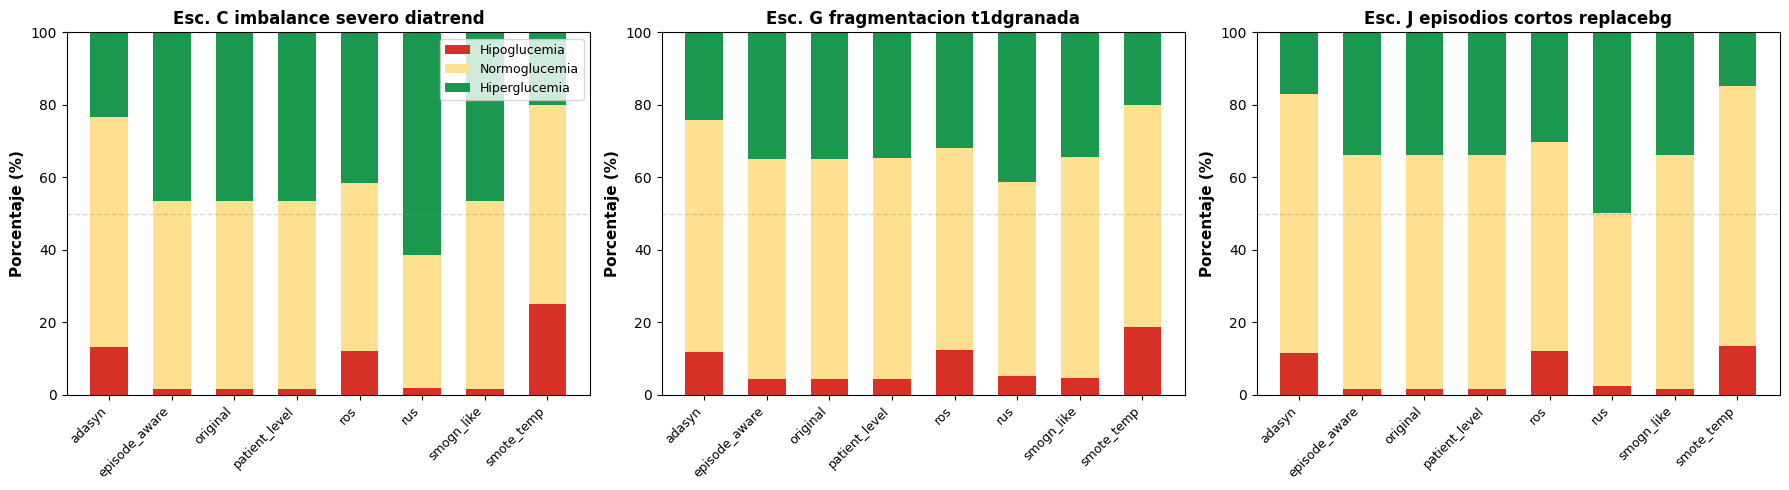

✓ Gráfico 1: balance de clases guardado


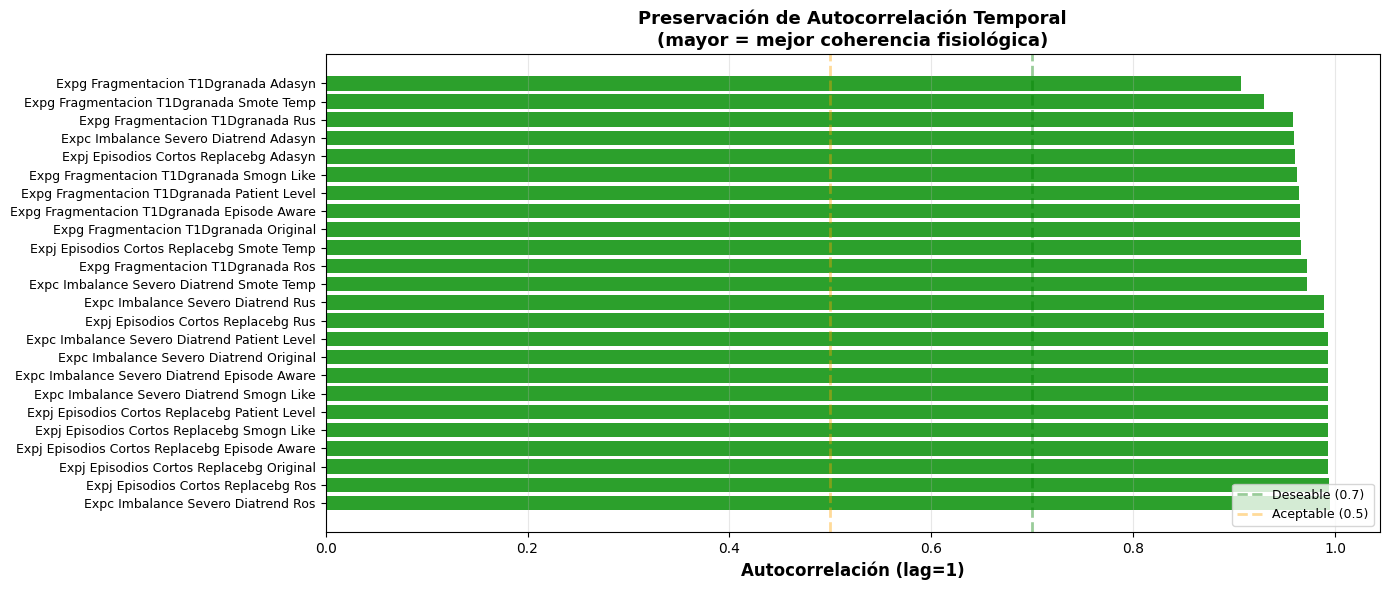

✓ Gráfico 2: autocorrelación guardado


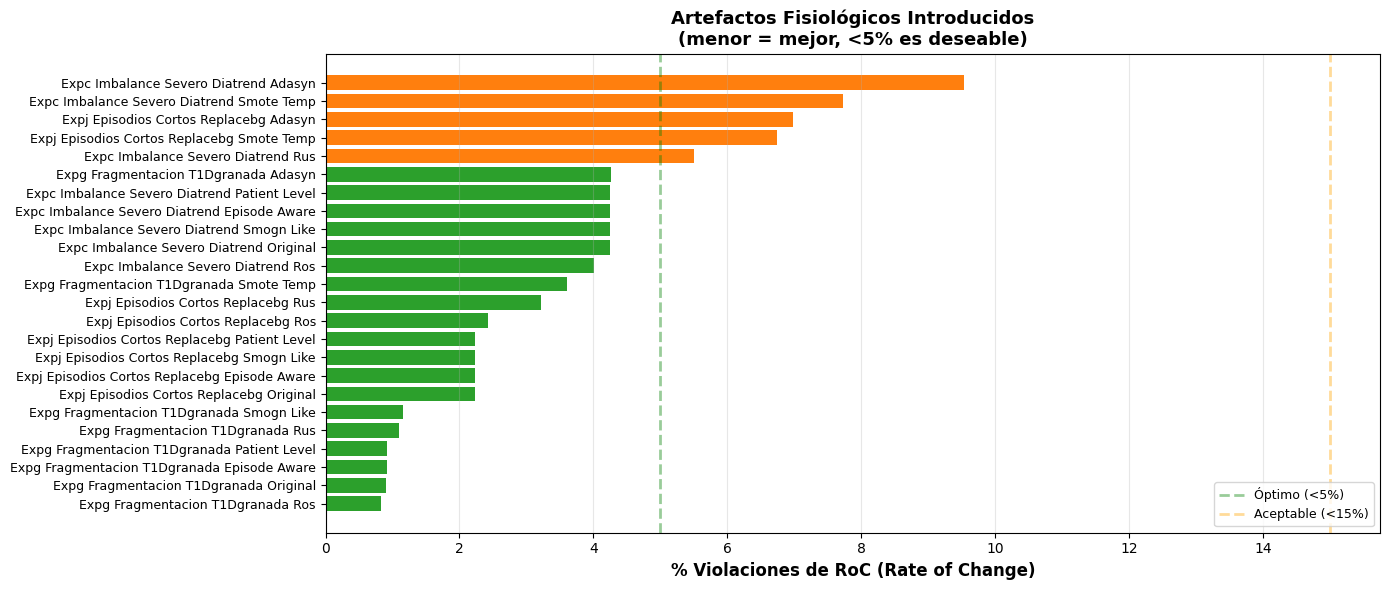

✓ Gráfico 3: violaciones RoC guardado


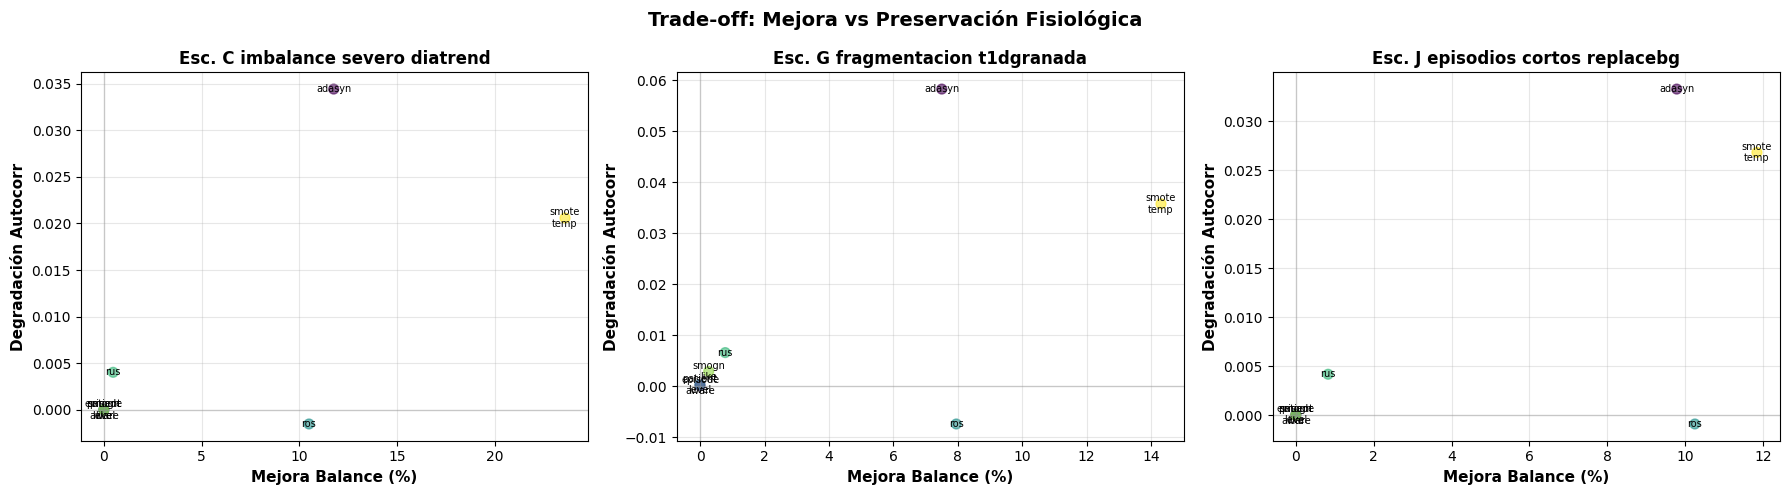

✓ Gráfico 4: trade-off guardado

RESUMEN CLÍNICO: RECOMENDACIONES POR ESCENARIO

📊 EXPC_IMBALANCE_SEVERO_DIATREND
------------------------------------------------------------------------------------------------------------------------
  ROS                  | Mejora:  +10.5% | Autocorr:  0.995 | RoC:  4.0% | Score:     96/100
  SMOTE_TEMP           | Mejora:  +23.6% | Autocorr:  0.973 | RoC:  7.7% | Score:     92/100
  ADASYN               | Mejora:  +11.8% | Autocorr:  0.959 | RoC:  9.5% | Score:     90/100
  RUS                  | Mejora:   +0.5% | Autocorr:  0.989 | RoC:  5.5% | Score:     47/100
  EPISODE_AWARE        | Mejora:   +0.0% | Autocorr:  0.993 | RoC:  4.2% | Score:     46/100
  SMOGN_LIKE           | Mejora:   +0.0% | Autocorr:  0.993 | RoC:  4.2% | Score:     46/100
  PATIENT_LEVEL        | Mejora:   +0.0% | Autocorr:  0.993 | RoC:  4.2% | Score:     46/100

✅ RECOMENDACIÓN: ROS (Score: 96/100)
   ├─ Mejora balance hipoglucemia: +10.5%
   ├─ Preserva autocorrelación: 0.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Crear directorio de figuras
figures_dir = Path('results') / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

# 1. Gráfico de distribución de clases
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scenarios_unique = list(scenario_names)
colors = ['#d73027', '#fee090', '#1a9850']

for idx, scenario in enumerate(scenarios_unique):
    scenario_data = compare[compare['dataset'].str.contains(scenario, na=False)]
    
    techniques = sorted(set([d.replace(scenario + '_', '') for d in scenario_data[scenario_data['metric'] == 'pct_hypo']['dataset'].values]))
    
    x_pos = list(range(len(techniques)))
    hypo_vals, normo_vals, hyper_vals = [], [], []
    
    for tech in techniques:
        dataset_name = f'{scenario}_{tech}'
        subset = scenario_data[scenario_data['dataset'] == dataset_name]
        
        hypo = subset[subset['metric'] == 'pct_hypo']['value'].values
        normo = subset[subset['metric'] == 'pct_normo']['value'].values
        hyper = subset[subset['metric'] == 'pct_hyper']['value'].values
        
        hypo_vals.append(float(hypo[0]) if len(hypo) > 0 else 0.0)
        normo_vals.append(float(normo[0]) if len(normo) > 0 else 0.0)
        hyper_vals.append(float(hyper[0]) if len(hyper) > 0 else 0.0)
    
    ax = axes[idx]
    width = 0.6
    ax.bar(x_pos, hypo_vals, width, label='Hipoglucemia', color=colors[0])
    ax.bar(x_pos, normo_vals, width, bottom=hypo_vals, label='Normoglucemia', color=colors[1])
    bottom = [h + n for h, n in zip(hypo_vals, normo_vals)]
    ax.bar(x_pos, hyper_vals, width, bottom=bottom, label='Hiperglucemia', color=colors[2])
    
    ax.set_ylabel('Porcentaje (%)', fontsize=11, fontweight='bold')
    ax.set_title(f'{scenario.replace("exp", "Esc. ").replace("_", " ")}', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(techniques, rotation=45, ha='right', fontsize=9)
    ax.set_ylim([0, 100])
    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.3, linewidth=1)
    
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(figures_dir / 'balance_por_tecnica.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico 1: balance de clases guardado")

# 2. Autocorrelación (CORREGIDO)
fig, ax = plt.subplots(figsize=(14, 6))

autocorr_data = compare[compare['metric'] == 'autocorr_lag1'].copy()
if len(autocorr_data) > 0:
    autocorr_pivot = autocorr_data.pivot_table(values='value', index='dataset', aggfunc='first')
    # CORRECCIÓN: usar 'value' en lugar de 0
    autocorr_pivot = autocorr_pivot.sort_values('value', ascending=False)
    
    colors_autocorr = ['#2ca02c' if float(x) > 0.7 else '#ff7f0e' if float(x) > 0.5 else '#d62728' 
                       for x in autocorr_pivot['value']]
    
    ax.barh(range(len(autocorr_pivot)), autocorr_pivot['value'], color=colors_autocorr)
    ax.set_yticks(range(len(autocorr_pivot)))
    ax.set_yticklabels([d.replace('_', ' ').title() for d in autocorr_pivot.index], fontsize=9)
    ax.set_xlabel('Autocorrelación (lag=1)', fontsize=12, fontweight='bold')
    ax.set_title('Preservación de Autocorrelación Temporal\n(mayor = mejor coherencia fisiológica)', 
                 fontsize=13, fontweight='bold')
    ax.axvline(x=0.7, color='green', linestyle='--', alpha=0.4, linewidth=2, label='Deseable (0.7)')
    ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.4, linewidth=2, label='Aceptable (0.5)')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'autocorrelacion_tecnicas.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Gráfico 2: autocorrelación guardado")

# 3. Violaciones de RoC (CORREGIDO)
fig, ax = plt.subplots(figsize=(14, 6))

roc_data = compare[compare['metric'] == 'roc_pct'].copy()
if len(roc_data) > 0:
    roc_pivot = roc_data.pivot_table(values='value', index='dataset', aggfunc='first')
    # CORRECCIÓN: usar 'value' en lugar de 0
    roc_pivot = roc_pivot.sort_values('value', ascending=True)
    
    colors_roc = ['#2ca02c' if float(x) < 5 else '#ff7f0e' if float(x) < 15 else '#d62728' 
                  for x in roc_pivot['value']]
    
    ax.barh(range(len(roc_pivot)), roc_pivot['value'], color=colors_roc)
    ax.set_yticks(range(len(roc_pivot)))
    ax.set_yticklabels([d.replace('_', ' ').title() for d in roc_pivot.index], fontsize=9)
    ax.set_xlabel('% Violaciones de RoC (Rate of Change)', fontsize=12, fontweight='bold')
    ax.set_title('Artefactos Fisiológicos Introducidos\n(menor = mejor, <5% es deseable)', 
                 fontsize=13, fontweight='bold')
    ax.axvline(x=5, color='green', linestyle='--', alpha=0.4, linewidth=2, label='Óptimo (<5%)')
    ax.axvline(x=15, color='orange', linestyle='--', alpha=0.4, linewidth=2, label='Aceptable (<15%)')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'roc_violations_tecnicas.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Gráfico 3: violaciones RoC guardado")

# 4. Trade-off
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(scenarios_unique):
    scenario_data = compare[compare['dataset'].str.contains(scenario, na=False)]
    
    original = scenario_data[scenario_data['dataset'] == f'{scenario}_original']
    if len(original) == 0:
        print(f"⚠ No original encontrado para {scenario}")
        continue
    
    orig_hypo = float(original[original['metric'] == 'pct_hypo']['value'].values[0])
    orig_autocorr = float(original[original['metric'] == 'autocorr_lag1']['value'].values[0])
    
    dataset_names = scenario_data[scenario_data['metric'] == 'pct_hypo']['dataset'].values
    techniques = sorted(set([d.replace(scenario + '_', '') for d in dataset_names if d != f'{scenario}_original']))
    
    x_vals, y_vals, sizes, labels = [], [], [], []
    
    for tech in techniques:
        dataset_name = f'{scenario}_{tech}'
        tech_data = scenario_data[scenario_data['dataset'] == dataset_name]
        
        hypo = tech_data[tech_data['metric'] == 'pct_hypo']['value'].values
        autocorr = tech_data[tech_data['metric'] == 'autocorr_lag1']['value'].values
        roc = tech_data[tech_data['metric'] == 'roc_pct']['value'].values
        
        if len(hypo) > 0 and len(autocorr) > 0 and len(roc) > 0:
            mejora = float(hypo[0]) - orig_hypo
            deg = orig_autocorr - float(autocorr[0])
            x_vals.append(mejora)
            y_vals.append(deg)
            sizes.append(max(50, float(roc[0]) * 5))
            labels.append(tech.replace('_', '\n'))
    
    if len(x_vals) > 0:
        ax = axes[idx]
        ax.scatter(x_vals, y_vals, s=sizes, alpha=0.6, c=range(len(x_vals)), cmap='viridis')
        
        for i, label in enumerate(labels):
            ax.annotate(label, (x_vals[i], y_vals[i]), fontsize=7, ha='center', va='center')
        
        ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=1)
        ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3, linewidth=1)
        ax.set_xlabel('Mejora Balance (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Degradación Autocorr', fontsize=11, fontweight='bold')
        ax.set_title(f'{scenario.replace("exp", "Esc. ").replace("_", " ")}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

plt.suptitle('Trade-off: Mejora vs Preservación Fisiológica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_dir / 'tradeoff_tecnicas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico 4: trade-off guardado")

# 5. Tabla resumen
print("\n" + "="*120)
print("RESUMEN CLÍNICO: RECOMENDACIONES POR ESCENARIO")
print("="*120)

for scenario in scenarios_unique:
    scenario_data = compare[compare['dataset'].str.contains(scenario, na=False)]
    original = scenario_data[scenario_data['dataset'] == f'{scenario}_original']
    
    if len(original) == 0:
        continue
    
    orig_hypo = float(original[original['metric'] == 'pct_hypo']['value'].values[0])
    
    dataset_names = scenario_data[scenario_data['metric'] == 'pct_hypo']['dataset'].values
    techniques = sorted(set([d.replace(scenario + '_', '') for d in dataset_names if d != f'{scenario}_original']))
    
    print(f"\n📊 {scenario.upper()}")
    print("-" * 120)
    
    results_summary = []
    
    for tech in techniques:
        dataset_name = f'{scenario}_{tech}'
        tech_data = scenario_data[scenario_data['dataset'] == dataset_name]
        
        hypo_val = tech_data[tech_data['metric'] == 'pct_hypo']['value'].values
        autocorr_val = tech_data[tech_data['metric'] == 'autocorr_lag1']['value'].values
        roc_val = tech_data[tech_data['metric'] == 'roc_pct']['value'].values
        
        if len(hypo_val) > 0 and len(autocorr_val) > 0 and len(roc_val) > 0:
            hypo = float(hypo_val[0])
            autocorr = float(autocorr_val[0])
            roc = float(roc_val[0])
            mejora = hypo - orig_hypo
            
            score_balance = min(50, mejora * 5) if mejora > 0 else 0
            score_fisiologia = max(0, 50 - roc)
            clinical_score = score_balance + score_fisiologia
            
            results_summary.append({
                'tecnica': tech.upper(),
                'mejora': f'{mejora:+.1f}%',
                'autocorr': f'{autocorr:.3f}',
                'roc': f'{roc:.1f}%',
                'score': clinical_score
            })
    
    results_summary.sort(key=lambda x: x['score'], reverse=True)
    
    if results_summary:
        for res in results_summary:
            print(f"  {res['tecnica']:20s} | Mejora: {res['mejora']:>7s} | "
                  f"Autocorr: {res['autocorr']:>6s} | RoC: {res['roc']:>5s} | "
                  f"Score: {res['score']:>6.0f}/100")
        
        best = results_summary[0]
        print(f"\n✅ RECOMENDACIÓN: {best['tecnica']} (Score: {best['score']:.0f}/100)")
        print(f"   ├─ Mejora balance hipoglucemia: {best['mejora']}")
        print(f"   ├─ Preserva autocorrelación: {best['autocorr']}")
        print(f"   └─ Artefactos fisiológicos: {best['roc']}")

print("\n" + "="*120)
print("✅ ANÁLISIS COMPLETADO - Gráficos en: " + str(figures_dir))
print("="*120)

## Conclusiones metodologicas para el TFM

Los resultados deben interpretarse como un compromiso entre sensibilidad a eventos raros y preservacion de la coherencia clinica. Cost-sensitive learning ofrece un baseline seguro. Las tecnicas basadas en episodios son preferibles cuando la continuidad y la autocorrelacion son criticas. Los metodos generativos deben justificarse con evidencia de que no introducen artefactos fisiologicos y de que respetan la estructura temporal observada en el EDA.